In [19]:
#from google.colab import drive
#drive.mount('/content/drive')

In [20]:
#import zipfile
#import os

#zip_file_path = '/content/drive/MyDrive/AI Workshop/Week 4/Data/Copy of devnagari digit.zip'
#data_path = '/content/drive/MyDrive/AI Workshop/Week 4/Data'
#destination_directory = os.path.dirname(data_path)

#with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    #zip_ref.extractall(destination_directory)

#print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")


In [21]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [22]:
#Manual Gradient
import numpy as np

def f(x):
    return x ** 2

def gradient(x):
    return 2 * x

x = 5.0
learning_rate = 0.1

for _ in range(10):
    x -= learning_rate * gradient(x)
    print(f"x: {x}, f(x): {f(x)}")

x: 4.0, f(x): 16.0
x: 3.2, f(x): 10.240000000000002
x: 2.56, f(x): 6.5536
x: 2.048, f(x): 4.194304
x: 1.6384, f(x): 2.68435456
x: 1.31072, f(x): 1.7179869184000003
x: 1.0485760000000002, f(x): 1.0995116277760004
x: 0.8388608000000002, f(x): 0.7036874417766403
x: 0.6710886400000001, f(x): 0.45035996273704976
x: 0.5368709120000001, f(x): 0.2882303761517119


In [23]:
#Gradient with TensorFlow
import tensorflow as tf

x = tf.Variable(5.0)

with tf.GradientTape() as tape:
    y = x ** 2

grad = tape.gradient(y, x)
print(grad.numpy())

10.0


In [24]:
#Matrix Multiplication Speed
import numpy as np
import tensorflow as tf
import time

size = (1000, 1000)

A = np.random.rand(*size)
B = np.random.rand(*size)

start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)

A_tf = tf.constant(A)
B_tf = tf.constant(B)

start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.04567980766296387
TensorFlow Time: 0.0006897449493408203


In [25]:
#Activation Function with Keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense

layer = Dense(64, activation='sigmoid')

In [26]:
#Layers in Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([ Dense(64, activation='relu', input_shape=(784,)),Dense(10, activation='softmax')])

# **Building a Simple Fully Connected Neural Network in Keras.**

LOad and Process the Data

In [27]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow


In [28]:

# Define dataset paths
train_dir = "/content/drive/MyDrive/AI Workshop/Week 4/DevanagariHandwrittenDigitDataset/Test"
test_dir = "/content/drive/MyDrive/AI Workshop/Week 4/DevanagariHandwrittenDigitDataset/Train"

# Define image size
img_height, img_width = 28, 28

In [29]:
# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)

      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)

In [30]:
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

Training set: (3000, 28, 28, 1), Labels: (3000, 10)
Testing set: (17000, 28, 28, 1), Labels: (17000, 10)


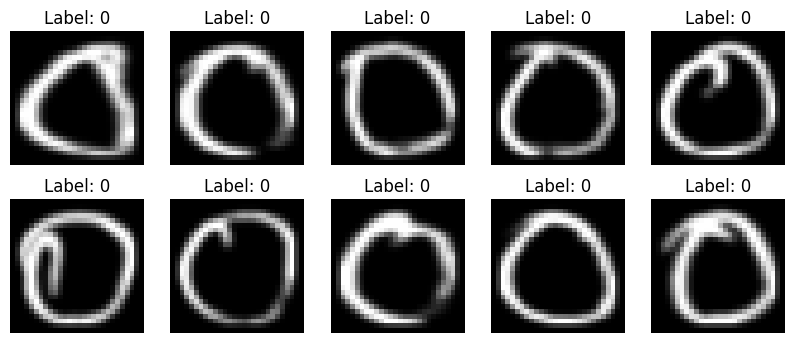

In [31]:
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

Loading and Preprocessing MNIST handwritten Digit Dataset

In [32]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test  = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build Model

In [33]:
#Example using Sequential API
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),

    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),

    keras.layers.Dense(10, activation="softmax"),
])

In [34]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
#Exmaple using Functional API
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
def build_functional_model():
  # Input layer
  inputs = keras.Input(shape=input_shape)
  # Flatten layer
  x = keras.layers.Flatten()(inputs)
  # Hidden layers
  x = keras.layers.Dense(64, activation="sigmoid")(x)
  x = keras.layers.Dense(128, activation="sigmoid")(x)
  x = keras.layers.Dense(256, activation="sigmoid")(x)
  # Output layer
  outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
  # Create model
  model = keras.Model(inputs=inputs, outputs=outputs)
  return model
# Build the model
functional_model = build_functional_model()
functional_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
#Syntax of model compile
model.compile(
  optimizer="sgd", # Stochastic Gradient Descent
  loss="categorical_crossentropy", # Loss function for multi-class classification
  metrics=["accuracy"] # Track accuracy during training
)

In [37]:
batch_size = 128
epochs = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
]

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.15,
    callbacks=callbacks,
)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1058 - loss: 2.3118 - val_accuracy: 0.1063 - val_loss: 2.3018
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1095 - loss: 2.3012 - val_accuracy: 0.1063 - val_loss: 2.3007
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1133 - loss: 2.2998 - val_accuracy: 0.1319 - val_loss: 2.3010
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1151 - loss: 2.2980 - val_accuracy: 0.1063 - val_loss: 2.3007
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1169 - loss: 2.2966 - val_accuracy: 0.1949 - val_loss: 2.2952
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1217 - loss: 2.2945 - val_accuracy: 0.1063 - val_loss: 2.2954
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1265 - loss: 2.2926 - val_accuracy: 0.1063 - val_loss: 2.2915
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1259 - loss: 2.2903 - val_accuracy: 0.

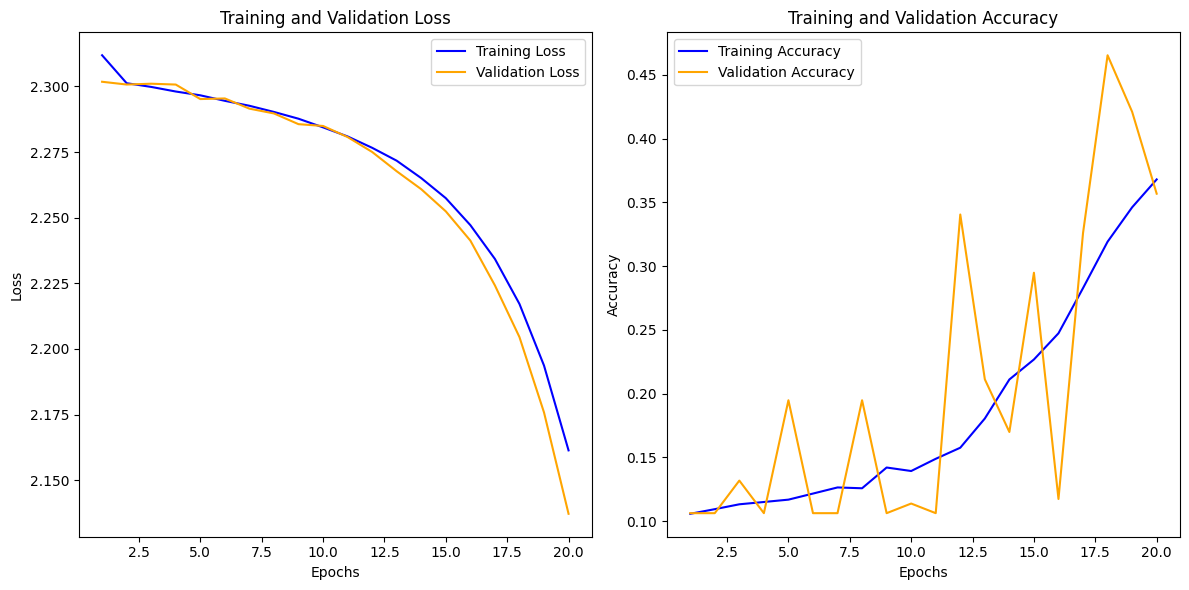

In [38]:
#code visualizing Model Training process
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
#MOdel Evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 2s - 5ms/step - accuracy: 0.3503 - loss: 2.1370
Test accuracy: 0.3503


Making Prediction with Keras

In [40]:
#Model.predict()
# Predict on test data
predictions = model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted label for first image: 7
True label for first image: 7


In [41]:
#Sve the model
model.save('mnist_fully_connected_model.h5')

In [42]:
#LOad model
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')

# Exercise: Building a Fully Connected Network for Devnagari Digit Classification

In [43]:
#Imports
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt

LOad the data

In [44]:

# Define dataset paths
train_dir = "/content/drive/MyDrive/AI Workshop/Week 4/DevanagariHandwrittenDigitDataset/Test"
test_dir = "/content/drive/MyDrive/AI Workshop/Week 4/DevanagariHandwrittenDigitDataset/Train"

# Define image size
img_height, img_width = 28, 28

In [45]:
# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)

      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)

In [46]:
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

Training set: (3000, 28, 28, 1), Labels: (3000, 10)
Testing set: (17000, 28, 28, 1), Labels: (17000, 10)


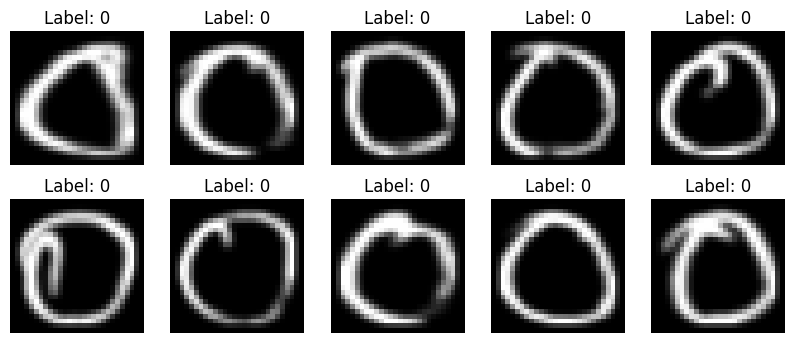

In [47]:
# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
  plt.title(f"Label: {np.argmax(y_train[i])}")
  plt.axis("off")
plt.show()

Build the FCN Model

In [48]:
model = keras.Sequential([
    keras.layers.Input(shape=(28,28,1)),
    keras.layers.Flatten(),

    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),

    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

COmpile the model

In [49]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train the model

In [50]:
history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.1229 - loss: 2.1900 - val_accuracy: 0.0000e+00 - val_loss: 5.9018
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2837 - loss: 2.0135 - val_accuracy: 0.0000e+00 - val_loss: 6.7089
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4600 - loss: 1.8251 - val_accuracy: 0.0000e+00 - val_loss: 6.8088
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6100 - loss: 1.5057 - val_accuracy: 0.0000e+00 - val_loss: 6.8630
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7113 - loss: 1.1873 - val_accuracy: 0.0000e+00 - val_loss: 6.9118
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7692 - loss: 0.9182 - val_accuracy: 0.0000e+00 - val_loss: 7.0599
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8017 - loss: 0.7197 - val_accuracy: 0.0000e+00 - val_loss: 7.2792
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8233 - loss: 0.5817 - va

Evaluate the mode

In [51]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7367 - loss: 2.0389
Test Accuracy: 0.7367058992385864
Test Loss: 2.0389440059661865


Save and load the model

In [52]:
# Save model
model.save("devnagari_fcn_model.h5")

# Load model
loaded_model = tf.keras.models.load_model("devnagari_fcn_model.h5")

# Evaluate loaded model
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7367 - loss: 2.0389
Loaded Model Accuracy: 0.7367058992385864


Predictions

In [53]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", true_labels[0])

532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Predicted: 0
Actual: 0


Expected deliverables

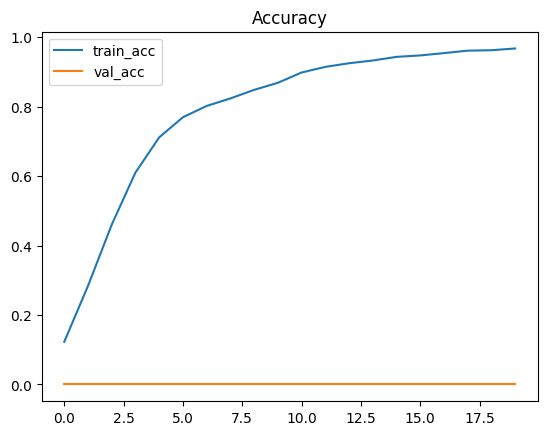

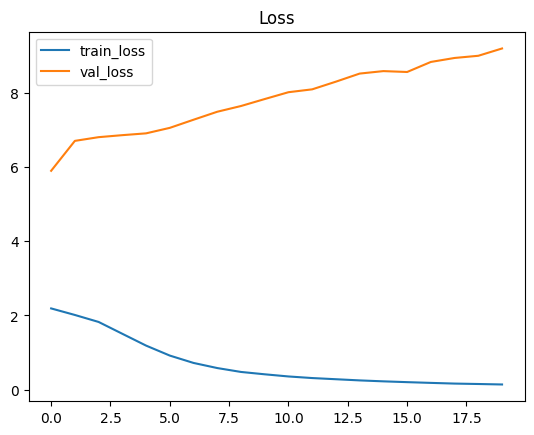

In [54]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()